In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path
from typing import Any

import numpy as np


STEP_RE = re.compile(r"^(y\+|y\-) step (\d+)/(\d+)$")
REQUIRED_MARKERS = ("marker_4", "marker_2", "marker_0")


def has_required_markers(entry: dict[str, Any]) -> bool:
    markers = entry.get("markers", {})
    return all(name in markers for name in REQUIRED_MARKERS)


def get_marker_xyz_raw(entry: dict[str, Any], marker_name: str) -> np.ndarray:
    markers = entry.get("markers", {})
    if marker_name not in markers:
        raise ValueError(
            f"{marker_name} not found in entry markers. "
            f"label={entry.get('label', '<no label>')}, "
            f"available={list(markers.keys())}"
        )
    m = markers[marker_name]
    return np.asarray([m["x"], m["y"], m["z"]], dtype=np.float64)


def remap_coordinates(p_raw: np.ndarray) -> np.ndarray:
    """
    Desired right-handed frame:
        x = slinky undeformed axis (flipped from raw x)
        y = depth                (ignored here -> 0)
        z = gravity direction    (-raw y)

    So:
        (x_new, y_new, z_new) = (-x_raw, 0, -y_raw)
    """
    return np.asarray([-p_raw[0], 0.0, -p_raw[1]], dtype=np.float64)


def get_marker_xyz(entry: dict[str, Any], marker_name: str) -> np.ndarray:
    return remap_coordinates(get_marker_xyz_raw(entry, marker_name))


def entry_to_q(entry: dict[str, Any]) -> np.ndarray:
    """
    Build:
        q = [x4,y4,z4,0, x2,y2,z2,0, x0,y0,z0]
    with all positions relative to marker_4.
    """
    p4 = get_marker_xyz(entry, "marker_4")
    p2 = get_marker_xyz(entry, "marker_2")
    p0 = get_marker_xyz(entry, "marker_0")

    p4_rel = p4 - p4
    p2_rel = p2 - p4
    p0_rel = p0 - p4

    return np.array(
        [
            p4_rel[0], p4_rel[1], p4_rel[2], 0.0,
            p2_rel[0], p2_rel[1], p2_rel[2], 0.0,
            p0_rel[0], p0_rel[1], p0_rel[2],
        ],
        dtype=np.float64,
    )


def extract_y_sweeps(data: list[dict[str, Any]]) -> list[tuple[str, list[dict[str, Any]]]]:
    sweeps: list[tuple[str, list[dict[str, Any]]]] = []

    current: list[dict[str, Any]] = []
    current_dir: str | None = None
    expected_step: int | None = None
    expected_total: int | None = None

    for entry in data:
        label = entry.get("label", "")
        m = STEP_RE.match(label)
        if m is None:
            continue

        direction = m.group(1)
        step_idx = int(m.group(2))
        total = int(m.group(3))

        if step_idx == 1:
            current = [entry]
            current_dir = direction
            expected_step = 2
            expected_total = total
            continue

        if (
            current
            and current_dir == direction
            and expected_step is not None
            and expected_total is not None
            and step_idx == expected_step
            and total == expected_total
        ):
            current.append(entry)
            expected_step += 1

            if step_idx == total:
                sweeps.append((direction, current))
                current = []
                current_dir = None
                expected_step = None
                expected_total = None

    return sweeps


def first_local_min_index(signal: np.ndarray) -> int:
    if signal.ndim != 1:
        raise ValueError("signal must be 1D")
    n = signal.shape[0]
    if n < 3:
        return 0

    for i in range(1, n - 1):
        if signal[i] <= signal[i - 1] and signal[i] <= signal[i + 1]:
            return i

    return int(np.argmin(signal))


def trim_first_yplus_initial_dip(
    sweeps: list[tuple[str, list[dict[str, Any]]]]
) -> list[tuple[str, list[dict[str, Any]]]]:
    out: list[tuple[str, list[dict[str, Any]]]] = []
    trimmed = False

    for direction, sweep in sweeps:
        if (not trimmed) and direction == "y+":
            qs = np.stack([entry_to_q(entry) for entry in sweep], axis=0)
            z0 = qs[:, 10]
            dip_idx = first_local_min_index(z0)
            sweep = sweep[dip_idx:]
            trimmed = True
        out.append((direction, sweep))

    return out


def build_direct_bc_from_qs(qs: np.ndarray) -> np.ndarray:
    """
    idx_b = [0,1,2,3,7,8,9,10]
    xb[t] stores the exact prescribed values at lambda index t.
    """
    xb = np.zeros((qs.shape[0], 8), dtype=np.float64)

    xb[:, 0] = qs[:, 0]    # x4
    xb[:, 1] = qs[:, 1]    # y4
    xb[:, 2] = qs[:, 2]    # z4
    xb[:, 3] = qs[:, 3]    # twist0
    xb[:, 4] = qs[:, 7]    # twist1
    xb[:, 5] = qs[:, 8]    # x0
    xb[:, 6] = qs[:, 9]    # y0
    xb[:, 7] = qs[:, 10]   # z0

    return xb


def json_to_train_npz(
    json_file: str | Path,
    train_file: str | Path = "train.npz",
    valid_file: str | Path = "valid.npz",
    trim_first_yplus_dip: bool = False,
) -> None:
    json_file = Path(json_file)
    train_file = Path(train_file)
    valid_file = Path(valid_file)

    with open(json_file, "r") as f:
        data = json.load(f)

    if not isinstance(data, list) or len(data) == 0:
        raise ValueError("Expected JSON file to contain a nonempty list of entries.")

    sweeps = extract_y_sweeps(data)
    if len(sweeps) == 0:
        raise ValueError("No complete y+ / y- sweeps found.")

    print(f"Found {len(sweeps)} raw y+/y- sweeps.")

    # Keep only sweeps where every entry has all required markers
    filtered_sweeps: list[tuple[str, list[dict[str, Any]]]] = []
    for i, (direction, sweep) in enumerate(sweeps):
        bad = [j for j, entry in enumerate(sweep) if not has_required_markers(entry)]
        if bad:
            print(
                f"Skipping sweep {i} ({direction}) because entries "
                f"{[b + 1 for b in bad]} are missing required markers."
            )
            continue
        filtered_sweeps.append((direction, sweep))

    sweeps = filtered_sweeps
    if len(sweeps) == 0:
        raise ValueError("No sweeps remain after filtering missing-marker entries.")

    print(f"Remaining valid sweeps: {len(sweeps)}")

    if trim_first_yplus_dip:
        sweeps = trim_first_yplus_initial_dip(sweeps)

    lengths = [len(sweep) for _, sweep in sweeps]
    if len(set(lengths)) != 1:
        raise ValueError(
            f"Sweep lengths are not all equal after extraction/trimming: {lengths}. "
            "Either disable trimming or crop manually."
        )

    qs_list = []
    xb_list = []
    dirs = []

    for i, (direction, sweep) in enumerate(sweeps):
        qs = np.stack([entry_to_q(entry) for entry in sweep], axis=0)
        xb = build_direct_bc_from_qs(qs)

        qs_list.append(qs)
        xb_list.append(xb)
        dirs.append(direction)

        print(f"Sweep {i}: direction={direction}, T={qs.shape[0]}, q_dim={qs.shape[1]}")

    qs_arr = np.stack(qs_list, axis=0)
    xb_arr = np.stack(xb_list, axis=0)

    print(f"qs_arr.shape = {qs_arr.shape}")
    print(f"xb_arr.shape = {xb_arr.shape}")

    idx_b = np.array([0, 1, 2, 3, 7, 8, 9, 10], dtype=np.int32)
    lambdas = np.linspace(0.0, 1.0, qs_arr.shape[1])

    # Alternate split: even-index sweeps -> train, odd-index sweeps -> valid
    train_idx = list(range(0, len(sweeps), 2))
    valid_idx = list(range(1, len(sweeps), 2))

    train_qs = qs_arr[train_idx]
    train_xb = xb_arr[train_idx]
    train_dirs = [dirs[i] for i in train_idx]

    valid_qs = qs_arr[valid_idx]
    valid_xb = xb_arr[valid_idx]
    valid_dirs = [dirs[i] for i in valid_idx]

    np.savez(
        train_file,
        qs=train_qs,
        idx_b=idx_b,
        xb=train_xb,
        lambdas=lambdas,
        sweep_directions=np.array(train_dirs, dtype=object),
    )

    np.savez(
        valid_file,
        qs=valid_qs,
        idx_b=idx_b,
        xb=valid_xb,
        lambdas=lambdas,
        sweep_directions=np.array(valid_dirs, dtype=object),
    )

    print("\nSaved train.npz and valid.npz")
    print(f"train.qs.shape = {train_qs.shape}")
    print(f"valid.qs.shape = {valid_qs.shape}")

In [2]:
input_data = "DLO_slinky_test_data_20260331_135325.json" 
# input_data = "DLO_slinky_test_data_20260330_194806.json" 
json_to_train_npz( json_file=input_data, train_file="train.npz", valid_file="valid.npz", trim_first_yplus_dip=False, )

Found 20 raw y+/y- sweeps.
Skipping sweep 4 (y+) because entries [34, 35] are missing required markers.
Skipping sweep 7 (y-) because entries [3] are missing required markers.
Skipping sweep 18 (y+) because entries [36, 37, 38, 39, 40] are missing required markers.
Skipping sweep 19 (y-) because entries [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40] are missing required markers.
Remaining valid sweeps: 16
Sweep 0: direction=y+, T=40, q_dim=11
Sweep 1: direction=y-, T=40, q_dim=11
Sweep 2: direction=y+, T=40, q_dim=11
Sweep 3: direction=y-, T=40, q_dim=11
Sweep 4: direction=y-, T=40, q_dim=11
Sweep 5: direction=y+, T=40, q_dim=11
Sweep 6: direction=y+, T=40, q_dim=11
Sweep 7: direction=y-, T=40, q_dim=11
Sweep 8: direction=y+, T=40, q_dim=11
Sweep 9: direction=y-, T=40, q_dim=11
Sweep 10: direction=y+, T=40, q_dim=11
Sweep 11: direction=y-, T=40, q_dim=11
Sweep 12: direction=y+, T=40

Shape of p0s: (775, 3)


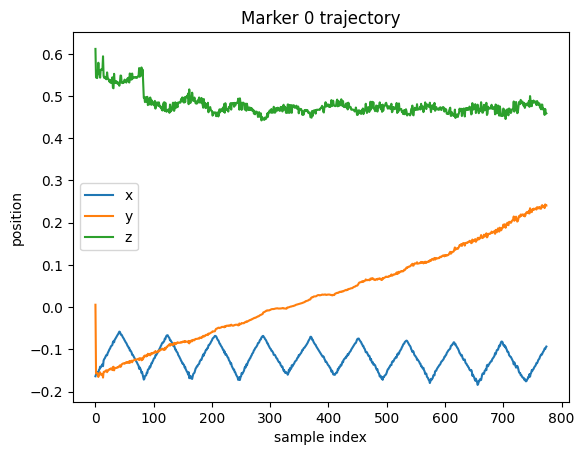

In [3]:
import matplotlib.pyplot as plt

# with open(input_data) as f:
with open(input_data, "r") as f:
    data = json.load(f)


# plot all markers trajectories in different subplots

p0s = []

for entry in data:
    if "markers" in entry and "marker_0" in entry["markers"]:
        m = entry["markers"]["marker_0"]
        p0s.append([m["x"], m["y"], m["z"]])

p0s = np.array(p0s)

print("Shape of p0s:", p0s.shape)

plt.figure()
plt.plot(p0s[:, 0], label="x")
plt.plot(p0s[:, 1], label="y")
plt.plot(p0s[:, 2], label="z")
plt.legend()
plt.title("Marker 0 trajectory")
plt.xlabel("sample index")
plt.ylabel("position")
plt.show()

Total segments found: 20


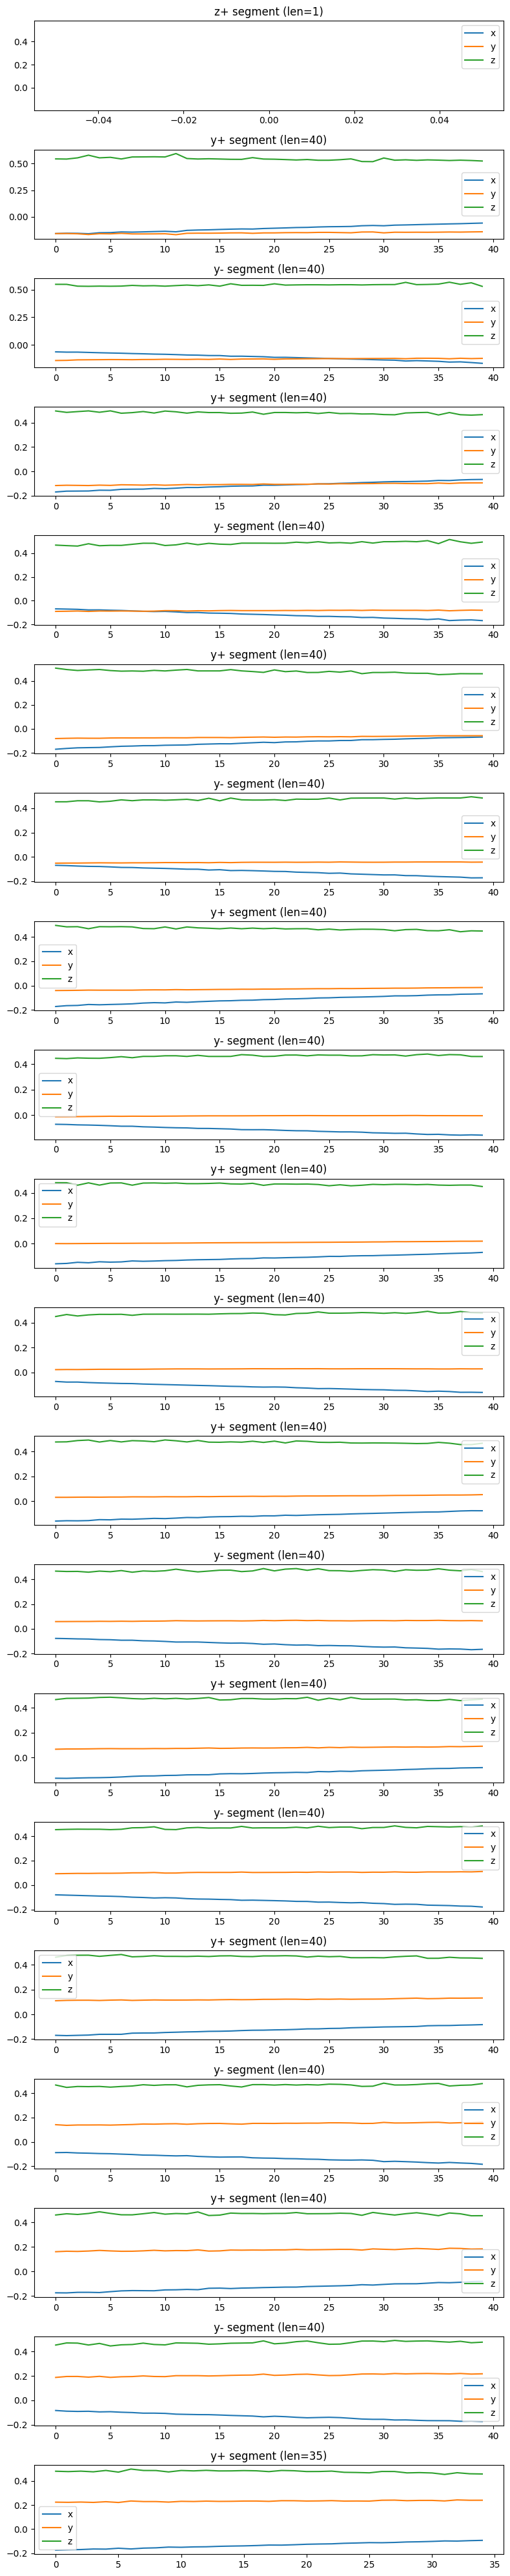

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
import re

with open(input_data) as f:
    data = json.load(f)

STEP_RE = re.compile(r"(y\+|y\-|z\+) step (\d+)/(\d+)")

segments = []
current_segment = []
current_label = None

for entry in data:
    label = entry.get("label", "")
    m = STEP_RE.match(label)
    if m is None:
        continue

    direction = m.group(1)
    step_idx = int(m.group(2))

    if "markers" not in entry or "marker_0" not in entry["markers"]:
        continue

    pos = entry["markers"]["marker_0"]
    point = [pos["x"], pos["y"], pos["z"]]

    # start new segment
    if step_idx == 1:
        if current_segment:
            segments.append((current_label, np.array(current_segment)))
        current_segment = []
        current_label = direction

    current_segment.append(point)

# append last
if current_segment:
    segments.append((current_label, np.array(current_segment)))

print(f"Total segments found: {len(segments)}")

# ================= PLOTTING =================

fig, axs = plt.subplots(len(segments), 1, figsize=(8, 2 * len(segments)))

if len(segments) == 1:
    axs = [axs]

for i, (label, seg) in enumerate(segments):
    axs[i].plot(seg[:, 0], label="x")
    axs[i].plot(seg[:, 1], label="y")
    axs[i].plot(seg[:, 2], label="z")
    axs[i].set_title(f"{label} segment (len={len(seg)})")
    axs[i].legend()

plt.tight_layout()
plt.show()

Markers found: ['marker_0', 'marker_1', 'marker_2', 'marker_3', 'marker_31', 'marker_4']
marker_0 shape: (775, 3)
marker_1 shape: (784, 3)
marker_2 shape: (826, 3)
marker_3 shape: (826, 3)
marker_31 shape: (3, 3)
marker_4 shape: (823, 3)


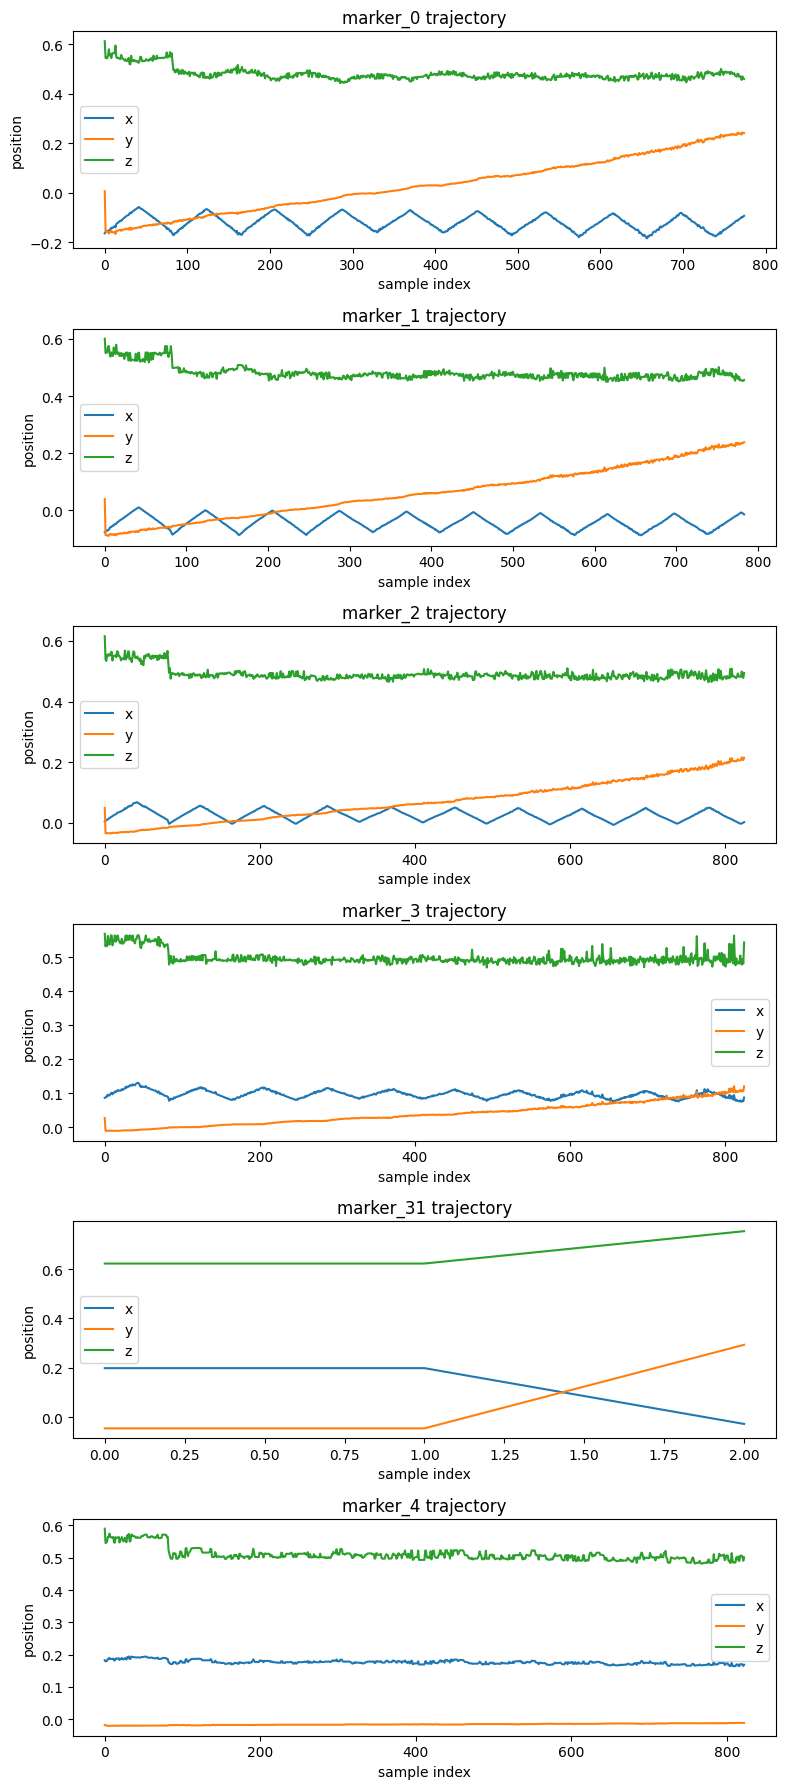

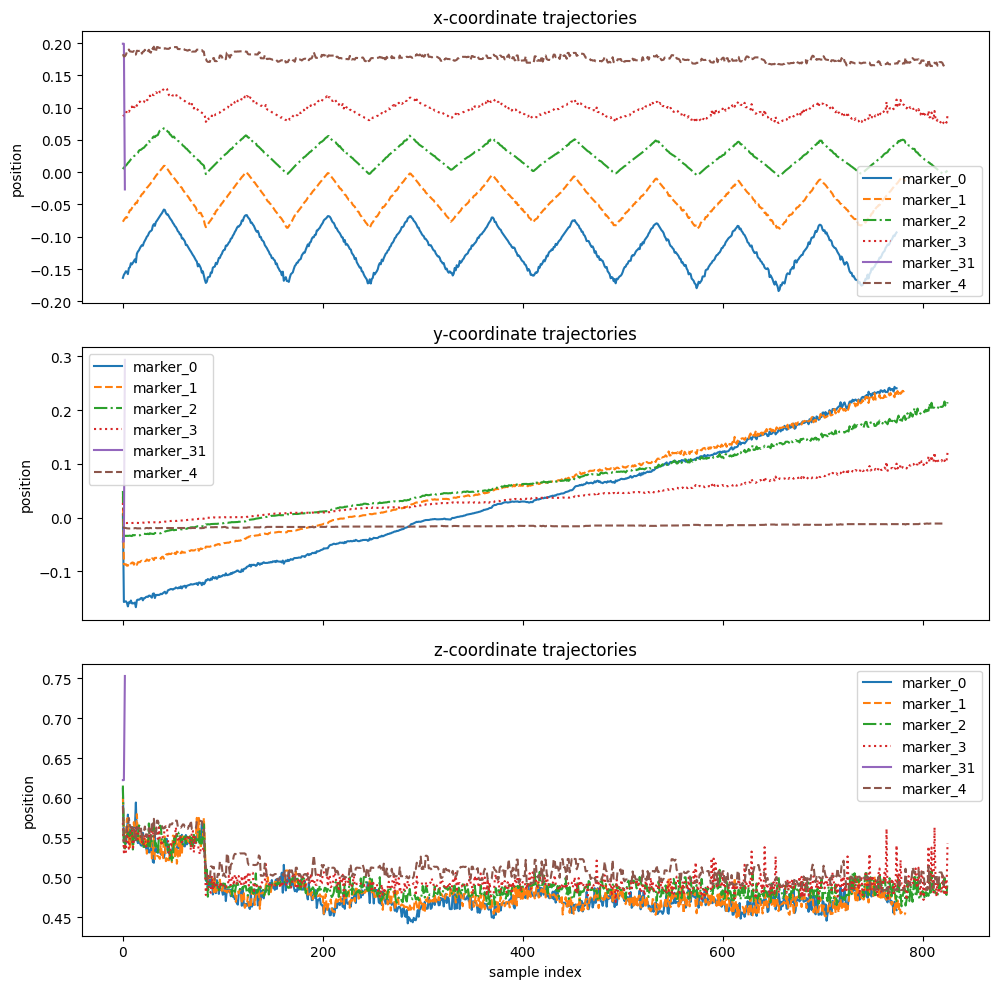

In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt

with open(input_data) as f:
    data = json.load(f)

# -------------------------------
# 1. Find all marker names
# -------------------------------
marker_names = set()
for entry in data:
    if "markers" in entry:
        marker_names.update(entry["markers"].keys())

marker_names = sorted(marker_names)
print("Markers found:", marker_names)

# -------------------------------
# 2. Collect trajectories
# -------------------------------
marker_trajs = {name: [] for name in marker_names}

for entry in data:
    if "markers" not in entry:
        continue

    for name in marker_names:
        if name in entry["markers"]:
            m = entry["markers"][name]
            marker_trajs[name].append([m["x"], m["y"], m["z"]])

# convert to numpy
for name in marker_names:
    marker_trajs[name] = np.array(marker_trajs[name])
    print(f"{name} shape:", marker_trajs[name].shape)

# -------------------------------
# 3. Plot
# -------------------------------
n_markers = len(marker_names)

fig, axs = plt.subplots(n_markers, 1, figsize=(8, 3 * n_markers))

# handle single marker case
if n_markers == 1:
    axs = [axs]

for i, name in enumerate(marker_names):
    traj = marker_trajs[name]

    axs[i].plot(traj[:, 0], label="x")
    axs[i].plot(traj[:, 1], label="y")
    axs[i].plot(traj[:, 2], label="z")

    axs[i].set_title(f"{name} trajectory")
    axs[i].set_xlabel("sample index")
    axs[i].set_ylabel("position")
    axs[i].legend()

plt.tight_layout()
plt.show()


############

# -------------------------------
# 3. Plot (grouped by coordinate)
# -------------------------------
linestyles = ['-', '--', '-.', ':']
colors = plt.cm.tab10.colors  # good default color cycle

fig, axs = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

coord_labels = ['x', 'y', 'z']

for i, coord in enumerate(coord_labels):
    ax = axs[i]

    for j, name in enumerate(marker_names):
        traj = marker_trajs[name]
        if traj.size == 0:
            continue

        linestyle = linestyles[j % len(linestyles)]
        color = colors[j % len(colors)]

        ax.plot(
            traj[:, i],
            label=name,
            linestyle=linestyle,
            color=color
        )

    ax.set_title(f"{coord}-coordinate trajectories")
    ax.set_ylabel("position")
    ax.legend()

axs[-1].set_xlabel("sample index")

plt.tight_layout()
plt.show()

Markers: ['marker_0', 'marker_1', 'marker_2', 'marker_3', 'marker_31', 'marker_4']
Total sweeps found: 20


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

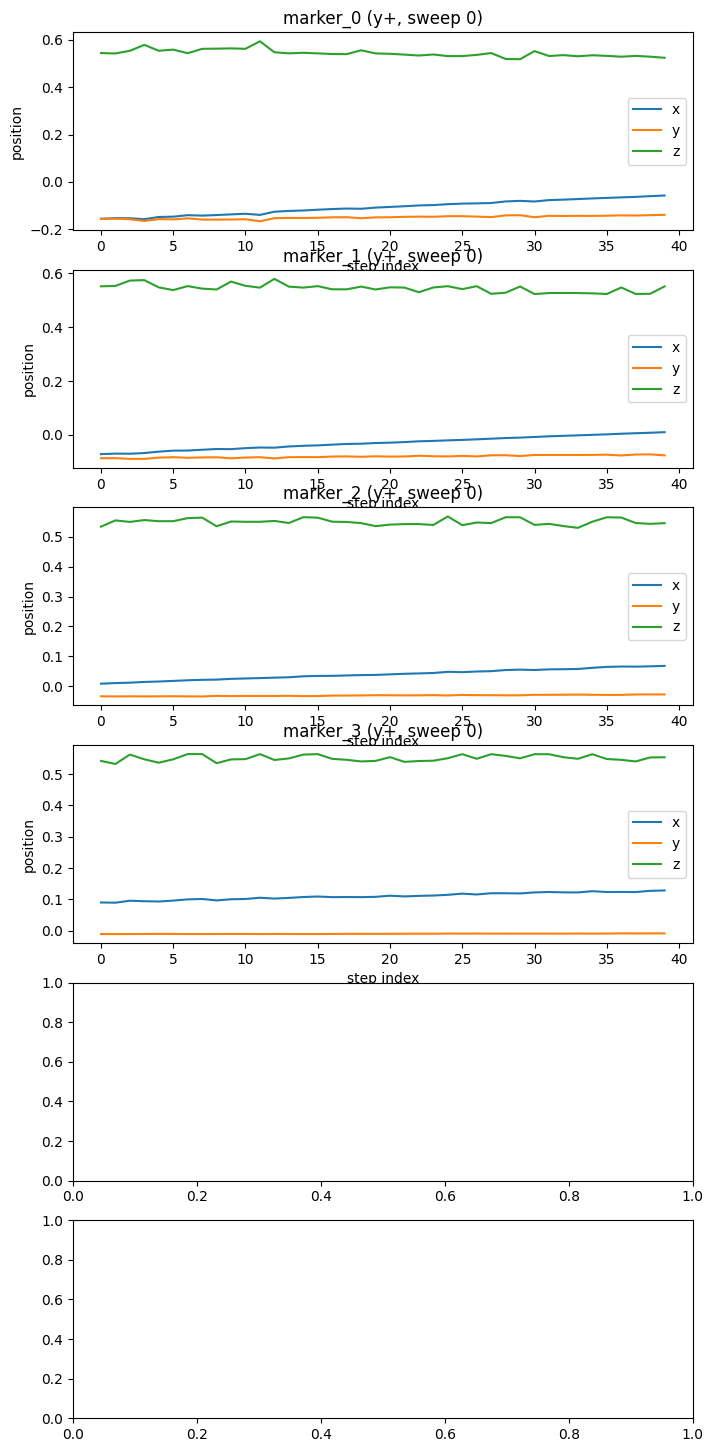

In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt
import re

with open(input_data) as f:
    data = json.load(f)

STEP_RE = re.compile(r"^(y\+|y\-) step (\d+)/(\d+)$")

# -------------------------------
# 1. Find all markers
# -------------------------------
marker_names = set()
for entry in data:
    if "markers" in entry:
        marker_names.update(entry["markers"].keys())

marker_names = sorted(marker_names)
print("Markers:", marker_names)

# -------------------------------
# 2. Extract y± sweeps
# -------------------------------
sweeps = []
current = []
current_dir = None
expected_step = None

for entry in data:
    label = entry.get("label", "")
    m = STEP_RE.match(label)
    if m is None:
        continue

    direction = m.group(1)
    step_idx = int(m.group(2))
    total = int(m.group(3))

    if step_idx == 1:
        current = [entry]
        current_dir = direction
        expected_step = 2
        continue

    if current and direction == current_dir and step_idx == expected_step:
        current.append(entry)
        expected_step += 1

        if step_idx == total:
            sweeps.append((current_dir, current))
            current = []
            current_dir = None
            expected_step = None

print(f"Total sweeps found: {len(sweeps)}")

# -------------------------------
# 3. Plot each sweep
# -------------------------------
for s_idx, (direction, sweep) in enumerate(sweeps):

    fig, axs = plt.subplots(len(marker_names), 1, figsize=(8, 3 * len(marker_names)))
    if len(marker_names) == 1:
        axs = [axs]

    for i, name in enumerate(marker_names):
        traj = []

        for entry in sweep:
            if name in entry["markers"]:
                m = entry["markers"][name]
                traj.append([m["x"], m["y"], m["z"]])

        traj = np.array(traj)

        axs[i].plot(traj[:, 0], label="x")
        axs[i].plot(traj[:, 1], label="y")
        axs[i].plot(traj[:, 2], label="z")

        axs[i].set_title(f"{name} ({direction}, sweep {s_idx})")
        axs[i].set_xlabel("step index")
        axs[i].set_ylabel("position")
        axs[i].legend()

    plt.tight_layout()
    plt.show()

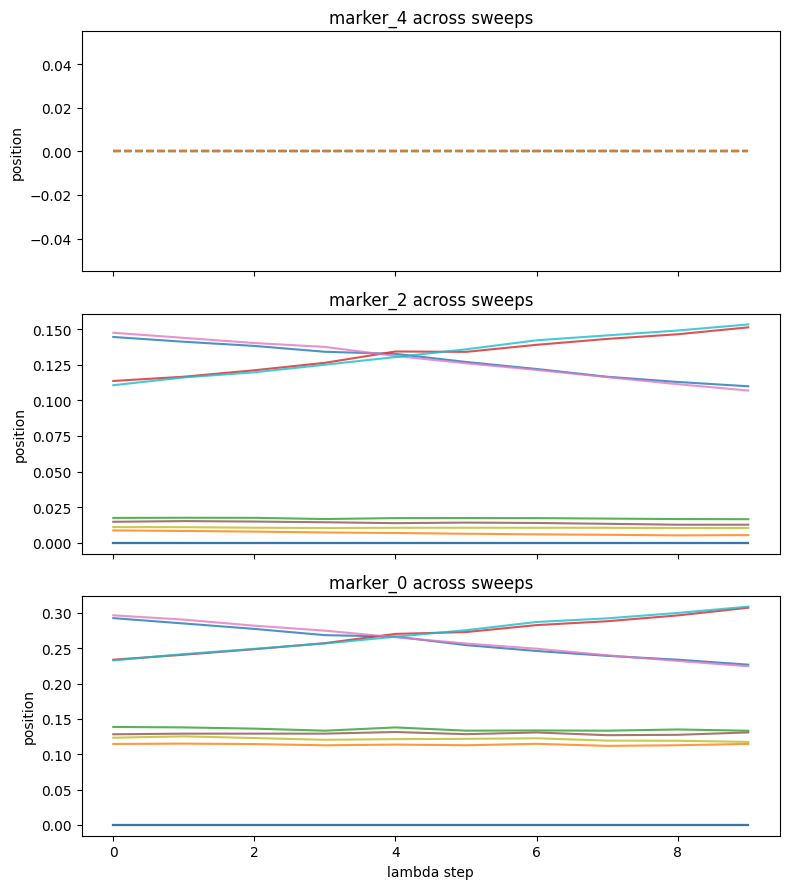

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("train_from_experiment.npz", allow_pickle=True)
qs = data["qs"]

n_sweeps = qs.shape[0]

fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

for s in range(n_sweeps):
    q = qs[s]

    m4 = q[:, 0:3]
    m2 = q[:, 4:7]
    m0 = q[:, 8:11]

    axs[0].plot(m4[:, 0], "--", alpha=0.8, label=f"sweep {s} x" if s == 0 else None)
    axs[0].plot(m4[:, 1], "--", alpha=0.8, label=f"sweep {s} y" if s == 0 else None)
    axs[0].plot(m4[:, 2], "--", alpha=0.8, label=f"sweep {s} z" if s == 0 else None)

    axs[1].plot(m2[:, 0], alpha=0.8)
    axs[1].plot(m2[:, 1], alpha=0.8)
    axs[1].plot(m2[:, 2], alpha=0.8)

    axs[2].plot(m0[:, 0], alpha=0.8)
    axs[2].plot(m0[:, 1], alpha=0.8)
    axs[2].plot(m0[:, 2], alpha=0.8)

axs[0].set_title("marker_4 across sweeps")
axs[1].set_title("marker_2 across sweeps")
axs[2].set_title("marker_0 across sweeps")

for ax in axs:
    ax.set_ylabel("position")

axs[2].set_xlabel("lambda step")
plt.tight_layout()
plt.show()

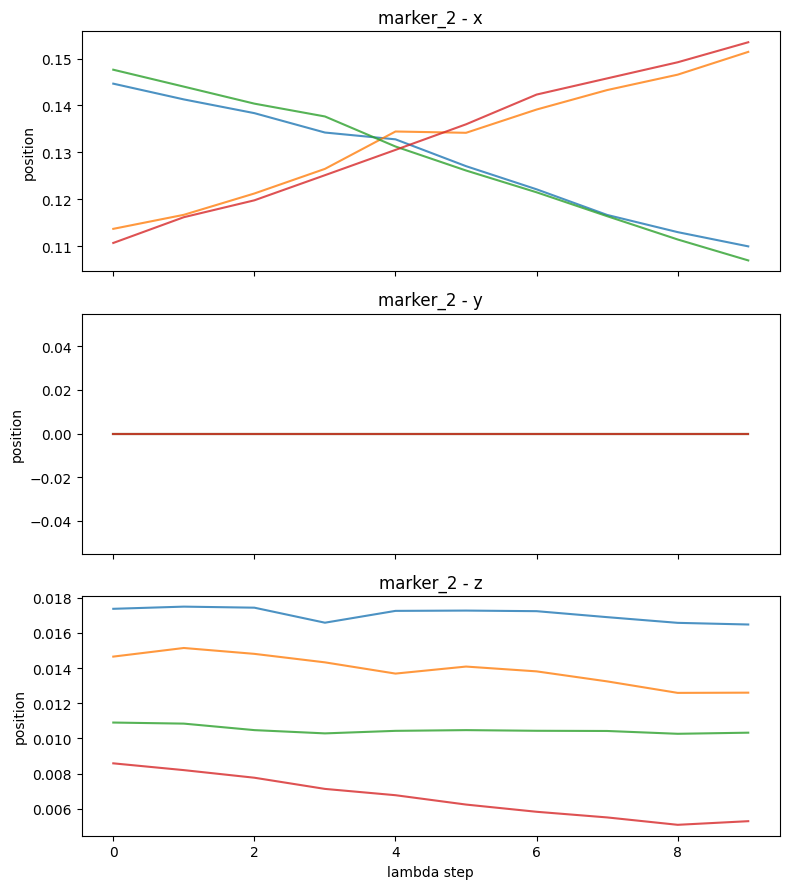

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

data = np.load("train_from_experiment.npz", allow_pickle=True)
qs = data["qs"]

n_sweeps = qs.shape[0]

fig, axs = plt.subplots(3, 1, figsize=(8, 9), sharex=True)

for s in range(n_sweeps):
    q = qs[s]

    # marker 2
    m2 = q[:, 4:7]

    axs[0].plot(m2[:, 0], alpha=0.8)
    axs[1].plot(m2[:, 1], alpha=0.8)
    axs[2].plot(m2[:, 2], alpha=0.8)

axs[0].set_title("marker_2 - x")
axs[1].set_title("marker_2 - y")
axs[2].set_title("marker_2 - z")

for ax in axs:
    ax.set_ylabel("position")

axs[2].set_xlabel("lambda step")

plt.tight_layout()
plt.show()

In [ ]:
start = np.array([0.1724633324071441, -0.012793774651351567, 0.3689216916171735 ])
end = np.array([-0.12996696354617737, 0.01085531091395733, 0.3810387333445698 ])
rod = end - start
rod[2] = 0.0
print(rod)
len = np.linalg.norm(rod)
print("Approximate slinky length in data:", len)

[-0.3024303   0.02364909  0.        ]
Approximate slinky length in data: 0.30335352834356305
